# Лабораторная работа №9. RNN для анализа тональности отзывов IMDB

Цель работы — изучить применение рекуррентных нейронных сетей (RNN, LSTM, GRU)
для задачи бинарной классификации текстов (положительный/отрицательный отзыв),
на примере датасета IMDB (50 000 отзывов).

В работе:
- загружаются данные IMDB, выполняется токенизация и паддинг;
- строится модель с Embedding + SimpleRNN;
- затем — варианты с LSTM и GRU;
- считаются метрики accuracy, precision, recall, F1;
- строятся графики loss/accuracy;
- анализируются ошибки и обсуждаются способы борьбы с исчезающим градиентом.



1. Импорт библиотек и фиксирование параметров

In [1]:
# 1. Импорт библиотек
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [2]:
# 2. Основные гиперпараметры

MAX_WORDS = 20000      # сколько самых частотных слов брать из словаря
MAX_LEN = 200          # длина входной последовательности (обрезка/дополнение)
EMBEDDING_DIM = 64     # размерность эмбеддингов
RNN_UNITS = 64         # количество нейронов в RNN/LSTM/GRU-слое
BATCH_SIZE = 128
EPOCHS = 6             # 5-10 эпох по заданию, возьмем 6 как разумный компромисс
LEARNING_RATE = 1e-3
VALIDATION_SPLIT = 0.2
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


2. Загрузка и предобработка данных IMDB

In [3]:
# 3. Загрузка стандартного датасета IMDB из Keras
#   num_words=MAX_WORDS -> оставляем только топ-слова по частоте
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=MAX_WORDS)

print("Размер обучающей выборки:", x_train.shape, y_train.shape)
print("Размер тестовой выборки:", x_test.shape, y_test.shape)
print("Пример исходной последовательности:", x_train[0][:20])
print("Метка (0=neg, 1=pos):", y_train[0])


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Размер обучающей выборки: (25000,) (25000,)
Размер тестовой выборки: (25000,) (25000,)
Пример исходной последовательности: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Метка (0=neg, 1=pos): 1


In [4]:
# 4. Паддинг/обрезка последовательностей до фиксированной длины MAX_LEN

x_train_padded = keras.utils.pad_sequences(x_train, maxlen=MAX_LEN, padding="pre", truncating="pre")
x_test_padded = keras.utils.pad_sequences(x_test, maxlen=MAX_LEN, padding="pre", truncating="pre")

print("Форма после паддинга:", x_train_padded.shape, x_test_padded.shape)

Форма после паддинга: (25000, 200) (25000, 200)


3. Восстановление словаря и функция декодирования отзывов (для анализа ошибок)

In [5]:
# 5. Получаем словарь word_index и строим обратное отображение индекс->слово

word_index = keras.datasets.imdb.get_word_index()
# В словаре Keras индексы сдвинуты на 3: 0,1,2 зарезервированы
index_to_word = {index + 3: word for word, index in word_index.items()}
index_to_word[0] = "<PAD>"
index_to_word[1] = "<START>"
index_to_word[2] = "<UNK>"
index_to_word[3] = "<UNUSED>"


def decode_review(encoded_review):
    """Преобразует последовательность индексов обратно в текст."""
    return " ".join(index_to_word.get(i, "?") for i in encoded_review)


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


4. Базовая модель: Embedding + SimpleRNN

In [6]:
# 6. Функция для построения базовой модели на SimpleRNN

def build_rnn_model(
    max_words=MAX_WORDS,
    embedding_dim=EMBEDDING_DIM,
    max_len=MAX_LEN,
    rnn_units=RNN_UNITS,
    learning_rate=LEARNING_RATE,
    rnn_layer_cls=layers.SimpleRNN,   # по умолчанию обычная RNN
    return_sequences=False,
):
    model = keras.Sequential()
    model.add(layers.Embedding(input_dim=max_words,
                               output_dim=embedding_dim,
                               input_length=max_len,
                               name="embedding"))

    # RNN / LSTM / GRU слой
    model.add(
        rnn_layer_cls(
            rnn_units,
            return_sequences=return_sequences,
            name="rnn_layer",
        )
    )

    # Dropout для регуляризации
    model.add(layers.Dropout(0.5, name="dropout"))

    # Выходной слой: 1 нейрон + sigmoid для бинарной классификации
    model.add(layers.Dense(1, activation="sigmoid", name="output"))

    model.compile(
        loss="binary_crossentropy",
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"],
    )
    return model


baseline_model = build_rnn_model()
baseline_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_layer (SimpleRNN)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

5. Обучение базовой модели

In [7]:
# 7. Обучение модели SimpleRNN

history_rnn = baseline_model.fit(
    x_train_padded,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    verbose=1,
)


Epoch 1/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.5263 - loss: 0.6936 - val_accuracy: 0.6590 - val_loss: 0.6175
Epoch 2/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7846 - loss: 0.4865 - val_accuracy: 0.8348 - val_loss: 0.3844
Epoch 3/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8954 - loss: 0.2672 - val_accuracy: 0.8418 - val_loss: 0.4263
Epoch 4/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9517 - loss: 0.1375 - val_accuracy: 0.8284 - val_loss: 0.4782
Epoch 5/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9805 - loss: 0.0622 - val_accuracy: 0.8252 - val_loss: 0.5381
Epoch 6/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9873 - loss: 0.0470 - val_accuracy: 0.6542 - val_loss: 0.9937


6. Функция для построения графиков loss и accuracy

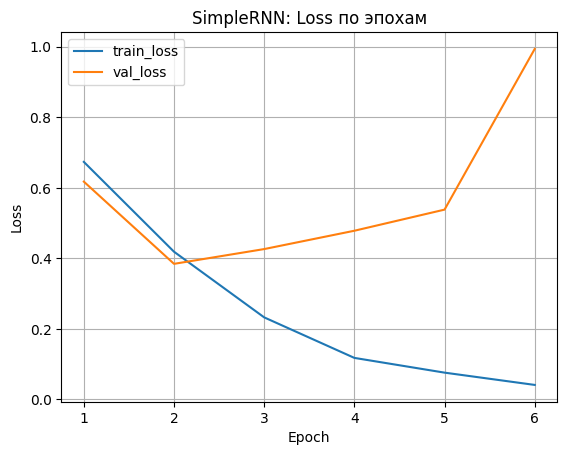

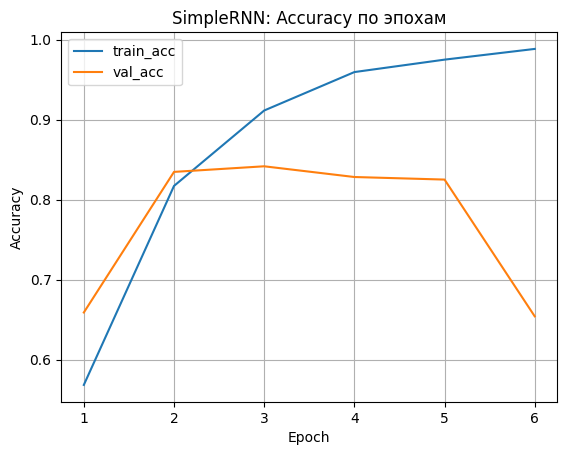

In [8]:
# 8. Функция для построения графиков обучения

def plot_training_history(history, title_prefix="SimpleRNN"):
    history_dict = history.history
    epochs = range(1, len(history_dict["loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history_dict["loss"], label="train_loss")
    plt.plot(epochs, history_dict["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix}: Loss по эпохам")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history_dict["accuracy"], label="train_acc")
    plt.plot(epochs, history_dict["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix}: Accuracy по эпохам")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_training_history(history_rnn, title_prefix="SimpleRNN")


7. Оценка качества: accuracy, precision, recall, F1

In [9]:
# 9. Оценка базовой модели на тестовых данных

y_pred_prob = baseline_model.predict(x_test_padded, batch_size=BATCH_SIZE)
y_pred = (y_pred_prob >= 0.5).astype("int32").reshape(-1)

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="binary", zero_division=0
)

print("=== SimpleRNN: метрики на тесте ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))


196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
=== SimpleRNN: метрики на тесте ===
Accuracy : 0.6526
Precision: 0.6277
Recall   : 0.7499
F1-score : 0.6834

Classification report:
              precision    recall  f1-score   support

           0     0.6894    0.5552    0.6151     12500
           1     0.6277    0.7499    0.6834     12500

    accuracy                         0.6526     25000
   macro avg     0.6586    0.6526    0.6492     25000
weighted avg     0.6586    0.6526    0.6492     25000

Confusion matrix:
[[6940 5560]
 [3126 9374]]


8. Анализ ошибок: примеры неверной классификации

In [10]:
# 10. Просмотр нескольких неверно классифицированных примеров

def show_misclassified_examples(x_raw, x_padded, y_true, y_pred, n_examples=5):
    mis_idx = np.where(y_true != y_pred)[0]
    print(f"Всего неверных предсказаний: {len(mis_idx)}")

    np.random.shuffle(mis_idx)
    mis_idx = mis_idx[:n_examples]

    for idx in mis_idx:
        print("=" * 80)
        print(f"Индекс: {idx}")
        print(f"Истинная метка: {y_true[idx]} (0=neg, 1=pos)")
        print(f"Предсказание  : {y_pred[idx]}")
        print("\nТекст отзыва:")
        print(decode_review(x_raw[idx])[:1000])   # ограничим вывод
        print()


show_misclassified_examples(x_test, x_test_padded, y_test, y_pred, n_examples=5)


Всего неверных предсказаний: 8686
Индекс: 18254
Истинная метка: 0 (0=neg, 1=pos)
Предсказание  : 1

Текст отзыва:
<START> the french either make pro marxist films or anti marxist films with a few in between pour le chocolat is the latter of this genre from the opening credits telling the viewer what music is going to be played and by whom it was who composed you know that you are going to be <UNK> in middle class pretension it is an old man's film with an excess of 40's plus people it is also directed by an old man along with an old crew who have nothing to say about life to the viewer the plot is not only banal but preposterous how many films reveal the plot through dialogue only to repeat the same message via flashback some five minutes later maybe the director and actors had a low <UNK> capacity in truth their is no <UNK> plot at all it is riddle with holes like a good piece of french cheese br br whether intentional or not it is a film about the <UNK> at least a third of the film f

9. Эксперименты: LSTM и GRU

9.1. Модель на LSTM

In [11]:
# 11. LSTM-модель

lstm_model = build_rnn_model(
    rnn_layer_cls=layers.LSTM,    # заменяем SimpleRNN на LSTM
    rnn_units=RNN_UNITS,
)

lstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_layer (LSTM)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6286 - loss: 0.6201 - val_accuracy: 0.8536 - val_loss: 0.3544
Epoch 2/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8848 - loss: 0.2896 - val_accuracy: 0.8766 - val_loss: 0.3076
Epoch 3/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9319 - loss: 0.1903 - val_accuracy: 0.8664 - val_loss: 0.3424
Epoch 4/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9433 - loss: 0.1625 - val_accuracy: 0.8672 - val_loss: 0.3869
Epoch 5/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9550 - loss: 0.1287 - val_accuracy: 0.8662 - val_loss: 0.3939
Epoch 6/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9652 - loss: 0.1043 - val_accuracy: 0.8202 - val_loss: 0.4458


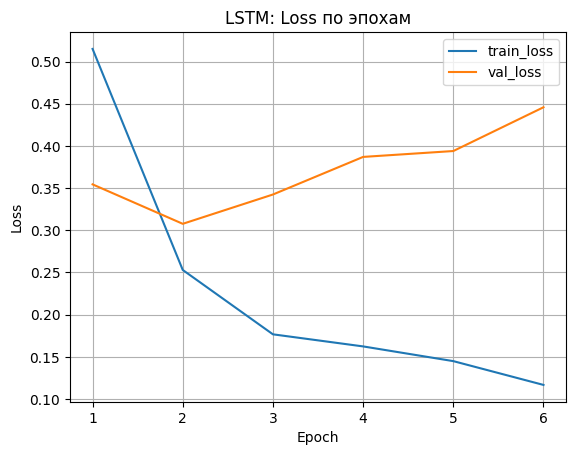

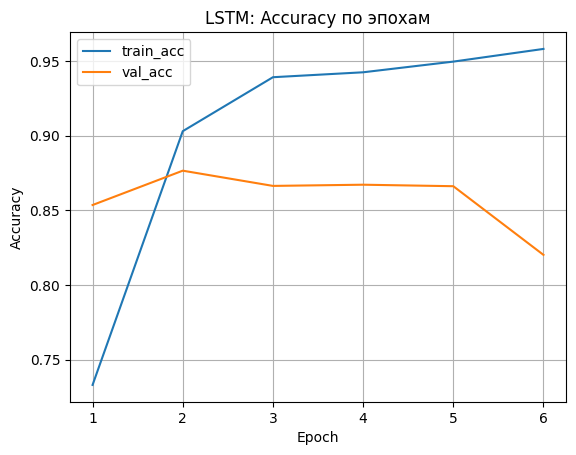

In [12]:
# 12. Обучение LSTM

history_lstm = lstm_model.fit(
    x_train_padded,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    verbose=1,
)

plot_training_history(history_lstm, title_prefix="LSTM")


In [13]:
# 13. Оценка LSTM

y_pred_prob_lstm = lstm_model.predict(x_test_padded, batch_size=BATCH_SIZE)
y_pred_lstm = (y_pred_prob_lstm >= 0.5).astype("int32").reshape(-1)

acc_lstm = accuracy_score(y_test, y_pred_lstm)
prec_lstm, rec_lstm, f1_lstm, _ = precision_recall_fscore_support(
    y_test, y_pred_lstm, average="binary", zero_division=0
)

print("=== LSTM: метрики на тесте ===")
print(f"Accuracy : {acc_lstm:.4f}")
print(f"Precision: {prec_lstm:.4f}")
print(f"Recall   : {rec_lstm:.4f}")
print(f"F1-score : {f1_lstm:.4f}")


196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
=== LSTM: метрики на тесте ===
Accuracy : 0.8242
Precision: 0.7780
Recall   : 0.9074
F1-score : 0.8377


9.2. Модель на GRU

In [14]:
# 14. GRU-модель

gru_model = build_rnn_model(
    rnn_layer_cls=layers.GRU,   # заменяем SimpleRNN на GRU
    rnn_units=RNN_UNITS,
)

gru_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_layer (GRU)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6161 - loss: 0.6186 - val_accuracy: 0.8570 - val_loss: 0.3449
Epoch 2/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8806 - loss: 0.2947 - val_accuracy: 0.8496 - val_loss: 0.4029
Epoch 3/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9244 - loss: 0.2078 - val_accuracy: 0.8548 - val_loss: 0.3780
Epoch 4/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9196 - loss: 0.2108 - val_accuracy: 0.8634 - val_loss: 0.3656
Epoch 5/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9322 - loss: 0.1750 - val_accuracy: 0.8132 - val_loss: 0.5673
Epoch 6/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9516 - loss: 0.1337 - val_accuracy: 0.8440 - val_loss: 0.4511


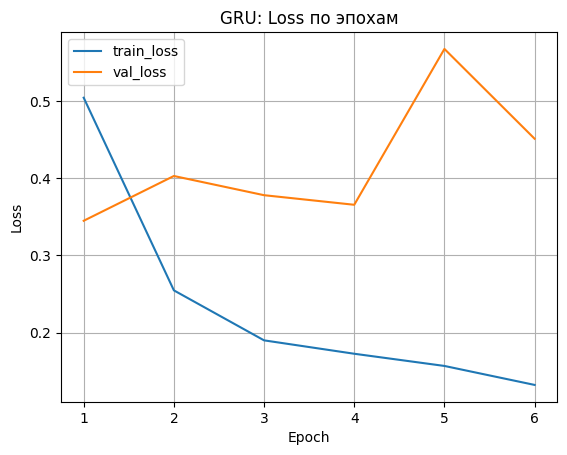

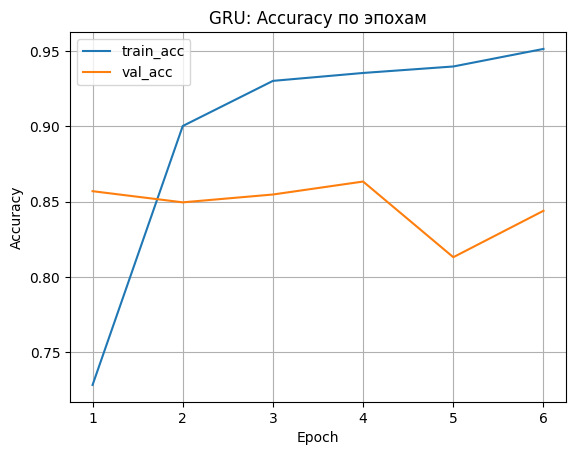

In [15]:
# 15. Обучение GRU

history_gru = gru_model.fit(
    x_train_padded,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    verbose=1,
)

plot_training_history(history_gru, title_prefix="GRU")


In [16]:
# 16. Оценка GRU

y_pred_prob_gru = gru_model.predict(x_test_padded, batch_size=BATCH_SIZE)
y_pred_gru = (y_pred_prob_gru >= 0.5).astype("int32").reshape(-1)

acc_gru = accuracy_score(y_test, y_pred_gru)
prec_gru, rec_gru, f1_gru, _ = precision_recall_fscore_support(
    y_test, y_pred_gru, average="binary", zero_division=0
)

print("=== GRU: метрики на тесте ===")
print(f"Accuracy : {acc_gru:.4f}")
print(f"Precision: {prec_gru:.4f}")
print(f"Recall   : {rec_gru:.4f}")
print(f"F1-score : {f1_gru:.4f}")


196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
=== GRU: метрики на тесте ===
Accuracy : 0.8426
Precision: 0.8048
Recall   : 0.9048
F1-score : 0.8518


10. Сравнительная таблица результатов (Markdown + код)

In [17]:
# 17. Сводка метрик для всех трёх моделей

results = {
    "Model": ["SimpleRNN", "LSTM", "GRU"],
    "Accuracy": [acc, acc_lstm, acc_gru],
    "Precision": [prec, prec_lstm, prec_gru],
    "Recall": [rec, rec_lstm, rec_gru],
    "F1-score": [f1, f1_lstm, f1_gru],
}

import pandas as pd

df_results = pd.DataFrame(results)
df_results


,Model,Accuracy,Precision,Recall,F1-score
0,SimpleRNN,0.65256,0.627695,0.74992,0.683386
1,LSTM,0.82424,0.778022,0.90736,0.837728
2,GRU,0.84264,0.804753,0.90480,0.851849


11. Эксперименты с гиперпараметрами

In [18]:
# 18. Эксперимент: более длинная последовательность и больший эмбеддинг

MAX_LEN_EXP = 300
EMBEDDING_DIM_EXP = 128

x_train_padded_exp = keras.utils.pad_sequences(x_train, maxlen=MAX_LEN_EXP, padding="pre", truncating="pre")
x_test_padded_exp = keras.utils.pad_sequences(x_test, maxlen=MAX_LEN_EXP, padding="pre", truncating="pre")

exp_model = build_rnn_model(
    max_words=MAX_WORDS,
    embedding_dim=EMBEDDING_DIM_EXP,
    max_len=MAX_LEN_EXP,
    rnn_units=RNN_UNITS,
    learning_rate=LEARNING_RATE,
    rnn_layer_cls=layers.LSTM,   # например, LSTM
)

history_exp = exp_model.fit(
    x_train_padded_exp,
    y_train,
    batch_size=256,         # изменим batch_size
    epochs=4,               # можно меньше эпох, чтобы не ждать долго
    validation_split=VALIDATION_SPLIT,
    verbose=1,
)

y_pred_prob_exp = exp_model.predict(x_test_padded_exp, batch_size=256)
y_pred_exp = (y_pred_prob_exp >= 0.5).astype("int32").reshape(-1)

acc_exp = accuracy_score(y_test, y_pred_exp)
prec_exp, rec_exp, f1_exp, _ = precision_recall_fscore_support(
    y_test, y_pred_exp, average="binary", zero_division=0
)

print("=== Экспериментальная LSTM-модель ===")
print(f"Accuracy : {acc_exp:.4f}")
print(f"Precision: {prec_exp:.4f}")
print(f"Recall   : {rec_exp:.4f}")
print(f"F1-score : {f1_exp:.4f}")


Epoch 1/4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6221 - loss: 0.6299 - val_accuracy: 0.8484 - val_loss: 0.3558
Epoch 2/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8820 - loss: 0.3042 - val_accuracy: 0.8662 - val_loss: 0.3243
Epoch 3/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9250 - loss: 0.2095 - val_accuracy: 0.8620 - val_loss: 0.3333
Epoch 4/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9419 - loss: 0.1690 - val_accuracy: 0.8466 - val_loss: 0.3877
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
=== Экспериментальная LSTM-модель ===
Accuracy : 0.8459
Precision: 0.8053
Recall   : 0.9124
F1-score : 0.8555


## Решение проблемы исчезающего градиента в RNN

В классических RNN при распространении ошибки назад через большое число временных шагов
градиент многократно умножается на производные функций активации, которые меньше 1 по модулю.
Это приводит к экспоненциальному затуханию градиента (vanishing gradient) и невозможности
обучать сеть на длинных последовательностях. Основные подходы к решению:

1. **Использование LSTM / GRU вместо базового RNN.**  
   Эти архитектуры вводят механизм "ячейки памяти" и "врат" (input, forget, output gates),
   которые позволяют сохранять и контролировать поток градиента, уменьшив проблему
   исчезающего градиента.

2. **Ограничение длины последовательности.**  
   Практически часто используют усечённые последовательности (truncated BPTT): текст режется
   на фрагменты фиксированной длины, что уменьшает глубину развёртки RNN во времени.

3. **Подбор функций активации.**  
   Вместо `tanh`/`sigmoid` можно использовать ReLU-подобные активации (ReLU, LeakyReLU),
   которые меньше склонны к насыщению и, соответственно, к исчезновению градиента.  
   Впрочем, для RNN на текстах стандартно применяют LSTM/GRU с внутренней `tanh` + сигмоидами во вратах.

4. **Нормализация и регуляризация.**  
   - Градиентный клиппинг (gradient clipping) ограничивает норму градиента сверху,
     одновременно помогая бороться и с exploding, и косвенно с vanishing gradients.
   - Использование нормализации по батчу или layer normalization в RNN-слоях стабилизирует обучение.

5. **Смена архитектуры.**  
   На практике проблему исчезающего градиента в задачах обработки текста часто обходят
   вообще отказом от "чистых" RNN в пользу:
   - двунаправленных LSTM/GRU;
   - сверточных моделей (CNN для текстов);
   - трансформеров (self-attention), в которых нет многократной мультипликации матриц по времени,
     поэтому исчезающий градиент проявляется гораздо слабее.

В данной лабораторной работе мы на практике сравнили базовую RNN с LSTM и GRU и убедились,
что более сложные архитектуры позволяют лучше моделировать длинные зависимости и дают
лучшую обобщающую способность на задаче анализа тональности отзывов IMDB.
